# VMC Training — Master Script

End-to-end variational Monte Carlo run: model → Hamiltonian → sampler → optimizer → training → diagnostics.

## Imports

In [12]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

from qvarnet.train import train
from qvarnet.models.exponential import LogExponentialMLPwithPenalty
from qvarnet.models.deep_set import DeepSet
from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian

## System

In [13]:
N_PARTICLES = 50
DIM         = 1
N_CHAINS    = 5_000
DoF         = N_PARTICLES * DIM
SHAPE       = (N_CHAINS, DoF)

## Model

In [14]:
model = DeepSet(
    phi_hidden_architecture=[2],
    F_hidden_architecture=[1],
    hidden_internal_dimension=1,
    n_particles=N_PARTICLES,
    # kernel_init=jax.nn.initializers.constant(0.0),
    # bias_init=jax.nn.initializers.constant(0.0),
    # kernel_init=jax.nn.initializers.normal(stddev=.01),
    # bias_init=jax.nn.initializers.normal(stddev=.01),
)
IS_LOG_MODEL = True

## Hamiltonian

In [15]:
OMEGA = 1.0

hamiltonian = HarmonicOscillatorHamiltonian(omega=OMEGA)

## Optimizer

In [32]:
LEARNING_RATE = 0.02

optimizer = optax.adam(learning_rate=LEARNING_RATE)

## Sampler

In [33]:
STEP_SIZE            = 0.5
CHAIN_LENGTH         = 10
# THERMALIZATION_STEPS = 10
THINNING_FACTOR      = 1
PBC                  = 40.0

sampler_params = {
    "step_size":            STEP_SIZE,
    "chain_length":         CHAIN_LENGTH + 1,
    "thermalization_steps": CHAIN_LENGTH,
    "thinning_factor":      THINNING_FACTOR,
    "PBC":                  PBC,
}

## Training

In [ ]:
import numpy as np

seed = np.random.randint(0, 10000)
N_EPOCHS             = 10_000
RNG_SEED             = seed
WARM_WALKERS         = True
IS_UPDATE_STEP_SIZE  = True
MIN_STEP             = 1e-5
MAX_STEP             = 5.0
SAVE_CHECKPOINTS     = False
CHECKPOINT_PATH      = "./"

history, cm_mean, cm_std = train(
    n_epochs=N_EPOCHS,
    shape=SHAPE,
    model=model,
    optimizer=optimizer,
    sampler_params=sampler_params,
    hamiltonian=hamiltonian,
    rng_seed=RNG_SEED,
    warm_walkers=WARM_WALKERS,
    is_update_step_size=IS_UPDATE_STEP_SIZE,
    is_log_model=IS_LOG_MODEL,
    min_step=MIN_STEP,
    max_step=MAX_STEP,
    save_checkpoints=SAVE_CHECKPOINTS,
    checkpoint_path=CHECKPOINT_PATH,
)

 11%|█         | 1071/10000 [00:35<02:20, 63.47it/s, E=27.86, sigma_E=3.68]

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 
 16%|█▌        | 1563/10000 [01:02<02:15, 62.23it/s, E=27.95, sigma_E=3.66]  

## Extract History

In [ ]:
energies   = np.array([s.energy for s in history]) / N_PARTICLES
stds       = np.array([s.std    for s in history]) / N_PARTICLES
acc_rates  = np.array([float(jnp.mean(s.acceptance_rate)) for s in history])
step_sizes = np.array([float(s.step_size) for s in history])
cm_mean_arr = np.array([float(x) for x in cm_mean])
cm_std_arr  = np.array([float(x) for x in cm_std])

steps   = np.arange(len(history))
E_EXACT = 0.5 * OMEGA  # ground state: 0.5 ℏω (ℏ = 1)

## Summary

In [ ]:
TAIL = 100
final_E   = energies[-TAIL:].mean()
final_std = stds[-TAIL:].mean()
error     = abs(final_E - E_EXACT)

print(f"Exact E₀             : {E_EXACT:.6f}")
print(f"Final E (last {TAIL}) : {final_E:.6f} ± {final_std:.6f}")
print(f"|E - E₀|             : {error:.6f}")
print(f"Relative error       : {error / E_EXACT * 100:.3f}%")
print(f"Final accept rate    : {acc_rates[-TAIL:].mean():.3f}")
print(f"Final step size      : {step_sizes[-1]:.4f}")

Exact E₀             : 0.500000
Final E (last 100) : 0.557044 ± 0.072305
|E - E₀|             : 0.057044
Relative error       : 11.409%
Final accept rate    : 0.500
Final step size      : 0.1305


## Plots

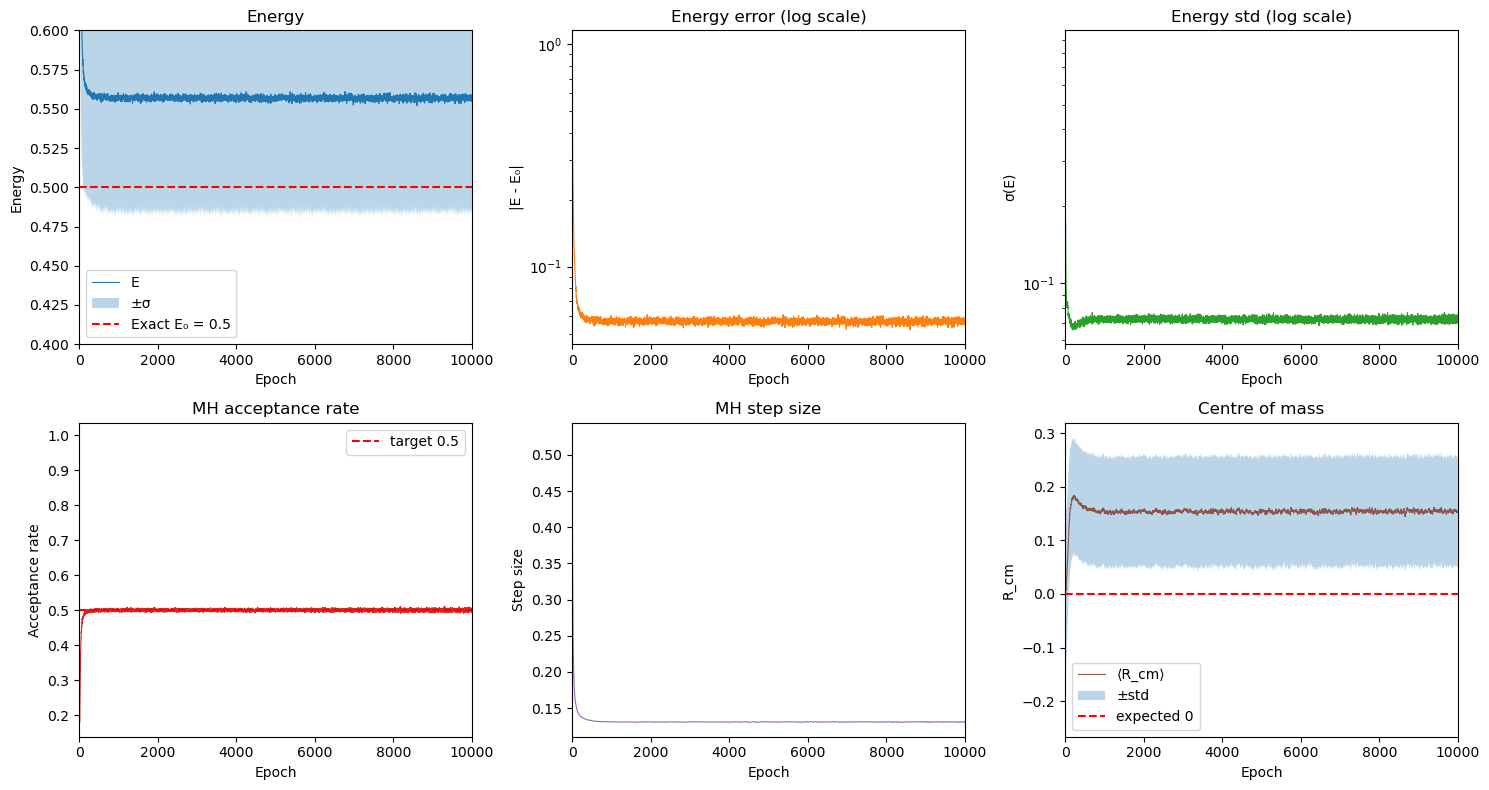

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# XRANGE = (850, 900)
XRANGE = (0, N_EPOCHS)

ax = axes[0, 0]
ax.plot(steps, energies, lw=0.8, label='E')
ax.fill_between(steps, energies - stds, energies + stds, alpha=0.3, label='±σ')
ax.axhline(E_EXACT, color='red', ls='--', label=f'Exact E₀ = {E_EXACT}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Energy'); ax.set_title('Energy'); ax.legend()
ax.set_xlim(XRANGE)
ax.set_ylim(0.4, 0.6)

ax = axes[0, 1]
ax.semilogy(steps, np.abs(energies - E_EXACT), lw=0.8, color='C1')
ax.set_xlabel('Epoch'); ax.set_ylabel('|E - E₀|'); ax.set_title('Energy error (log scale)')
ax.set_xlim(XRANGE)

ax = axes[0, 2]
ax.semilogy(steps, stds, lw=0.8, color='C2')
ax.set_xlabel('Epoch'); ax.set_ylabel('σ(E)'); ax.set_title('Energy std (log scale)')
ax.set_xlim(XRANGE)

ax = axes[1, 0]
ax.plot(steps, acc_rates, lw=0.8, color='C3')
ax.axhline(0.5, color='red', ls='--', label='target 0.5')
ax.set_xlabel('Epoch'); ax.set_ylabel('Acceptance rate'); ax.set_title('MH acceptance rate'); ax.legend()
ax.set_xlim(XRANGE)

ax = axes[1, 1]
ax.plot(steps, step_sizes, lw=0.8, color='C4')
ax.set_xlabel('Epoch'); ax.set_ylabel('Step size'); ax.set_title('MH step size')
ax.set_xlim(XRANGE)

ax = axes[1, 2]
ax.plot(steps, cm_mean_arr, lw=0.8, color='C5', label='⟨R_cm⟩')
ax.fill_between(steps, cm_mean_arr - cm_std_arr, cm_mean_arr + cm_std_arr, alpha=0.3, label='±std')
ax.axhline(0.0, color='red', ls='--', label='expected 0')
ax.set_xlabel('Epoch'); ax.set_ylabel('R_cm'); ax.set_title('Centre of mass'); ax.legend()
ax.set_xlim(XRANGE)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Parameter / Gradient Dashboard

In [22]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from plot_param_dashboard import compute_stats, save_stats, load_stats, plot_dashboard

param_stats = compute_stats(history, target='params', store_all=True)
grad_stats  = compute_stats(history, target='grads', store_all=True)

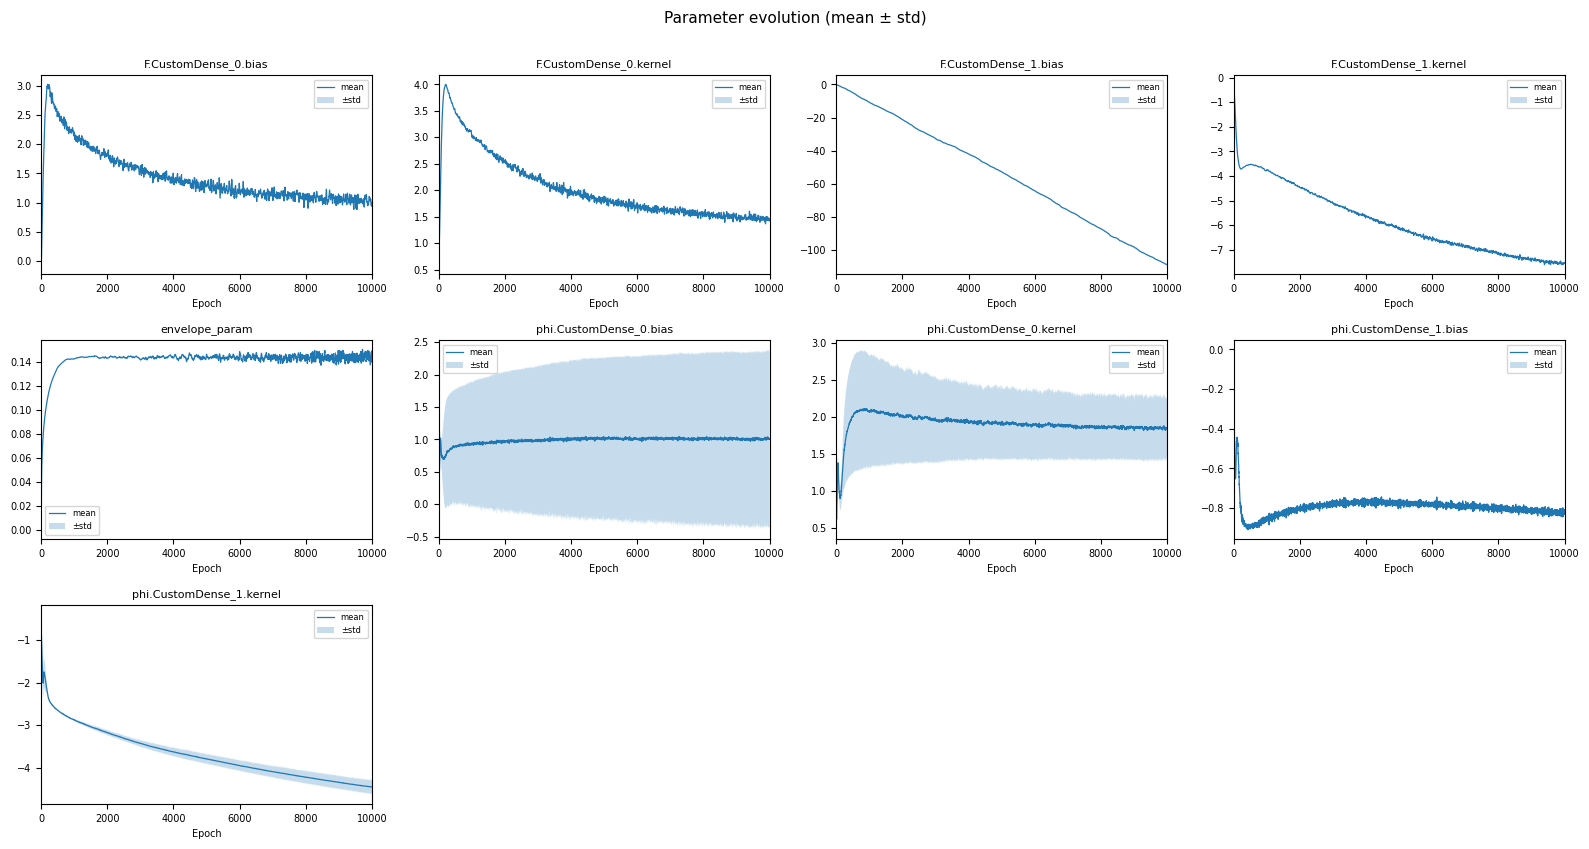

In [23]:
plot_dashboard(param_stats, mode='mean_std', title='Parameter evolution (mean ± std)', xrange=XRANGE);

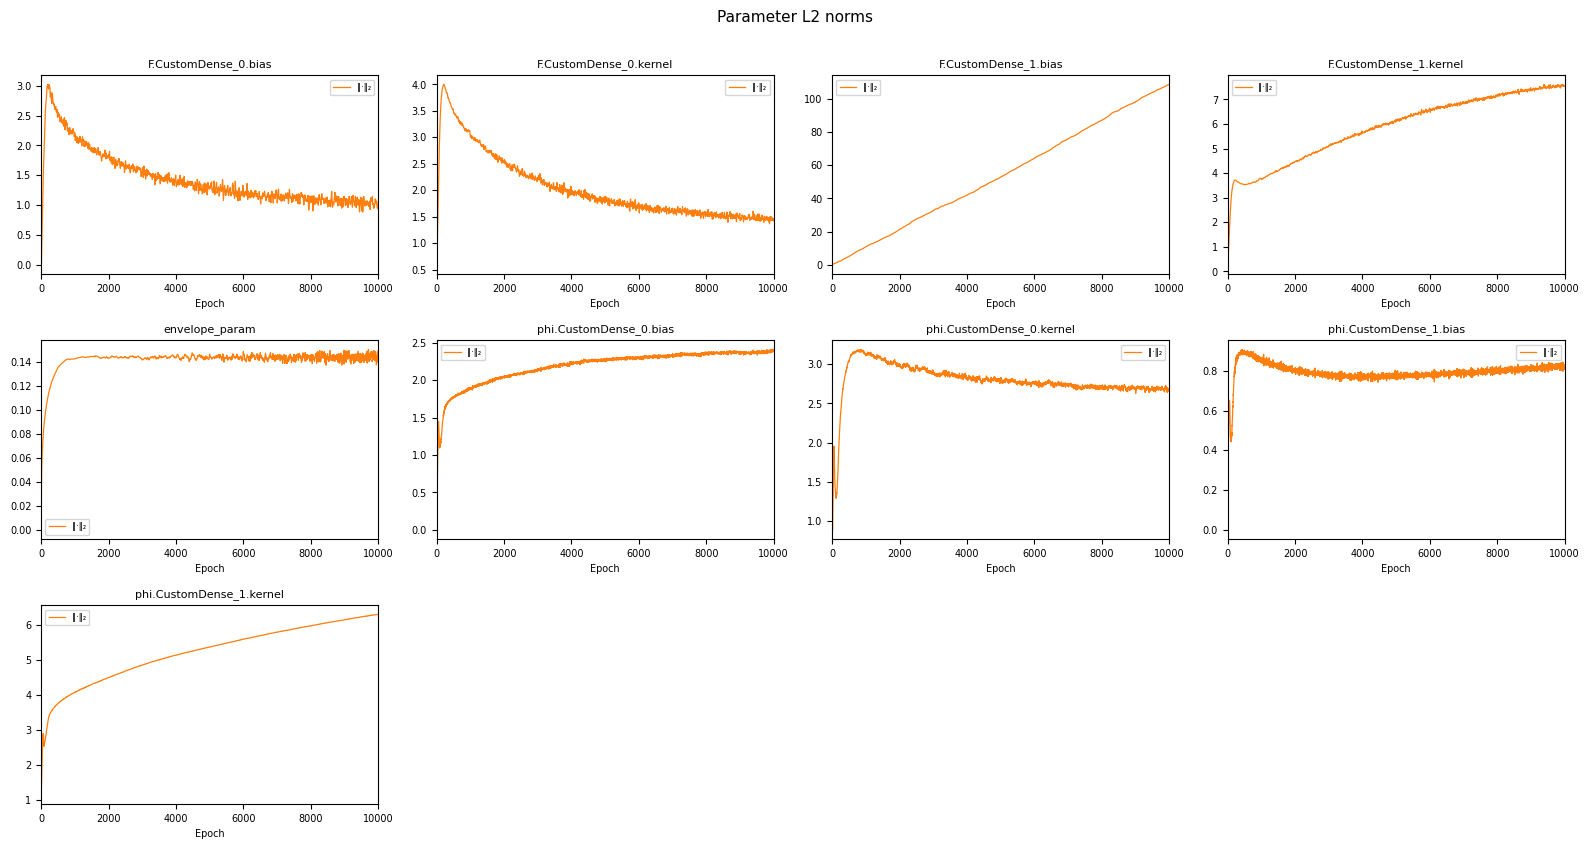

In [24]:
plot_dashboard(param_stats, mode='norm', title='Parameter L2 norms', xrange=XRANGE);

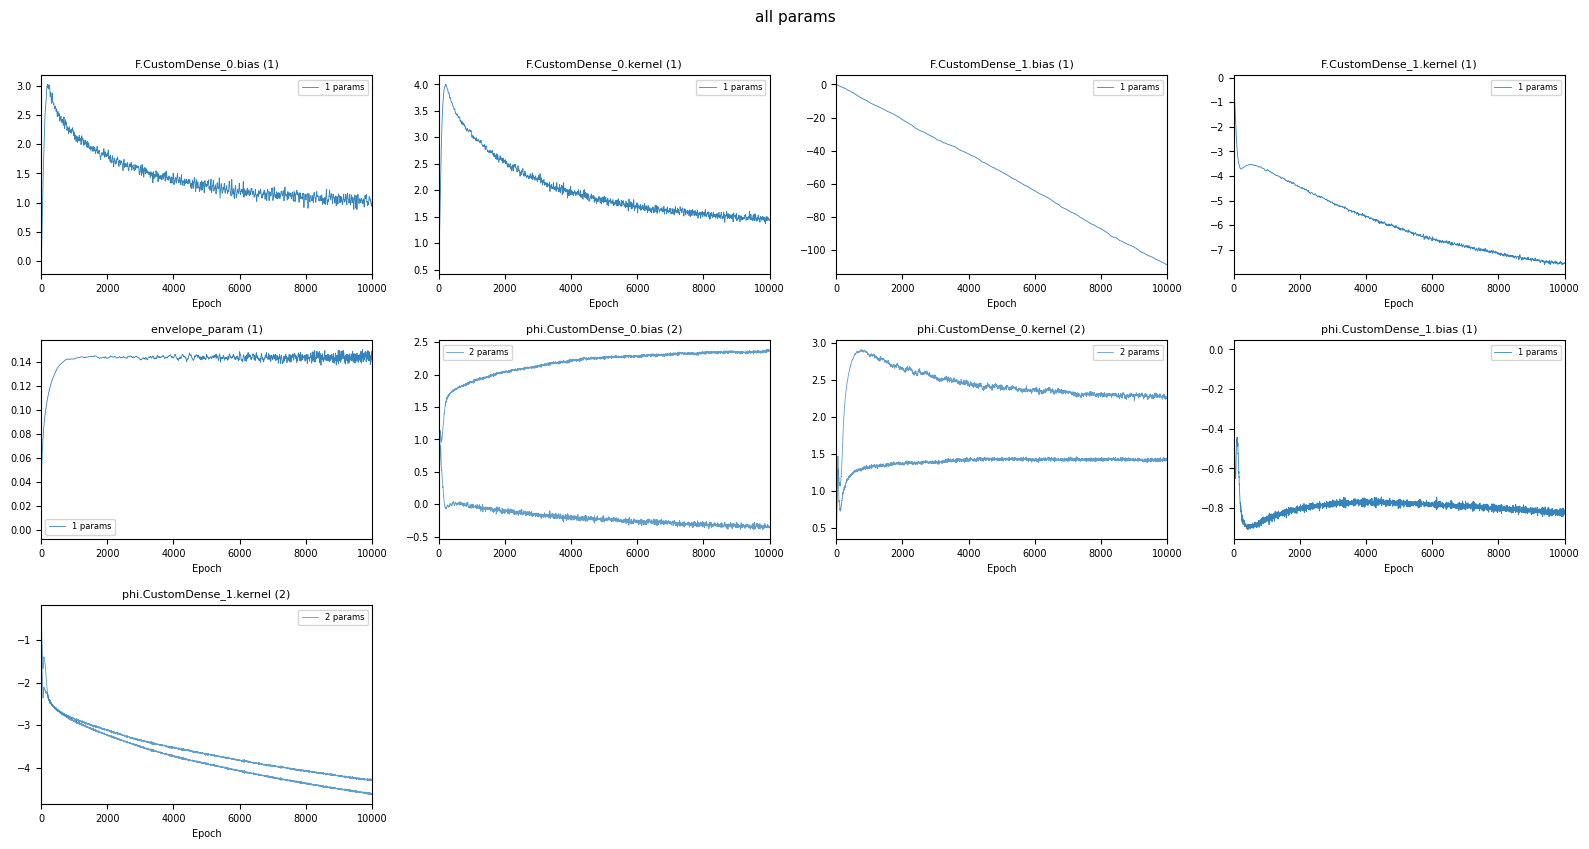

In [25]:
plot_dashboard(param_stats, mode='all', title='all params', xrange=XRANGE);

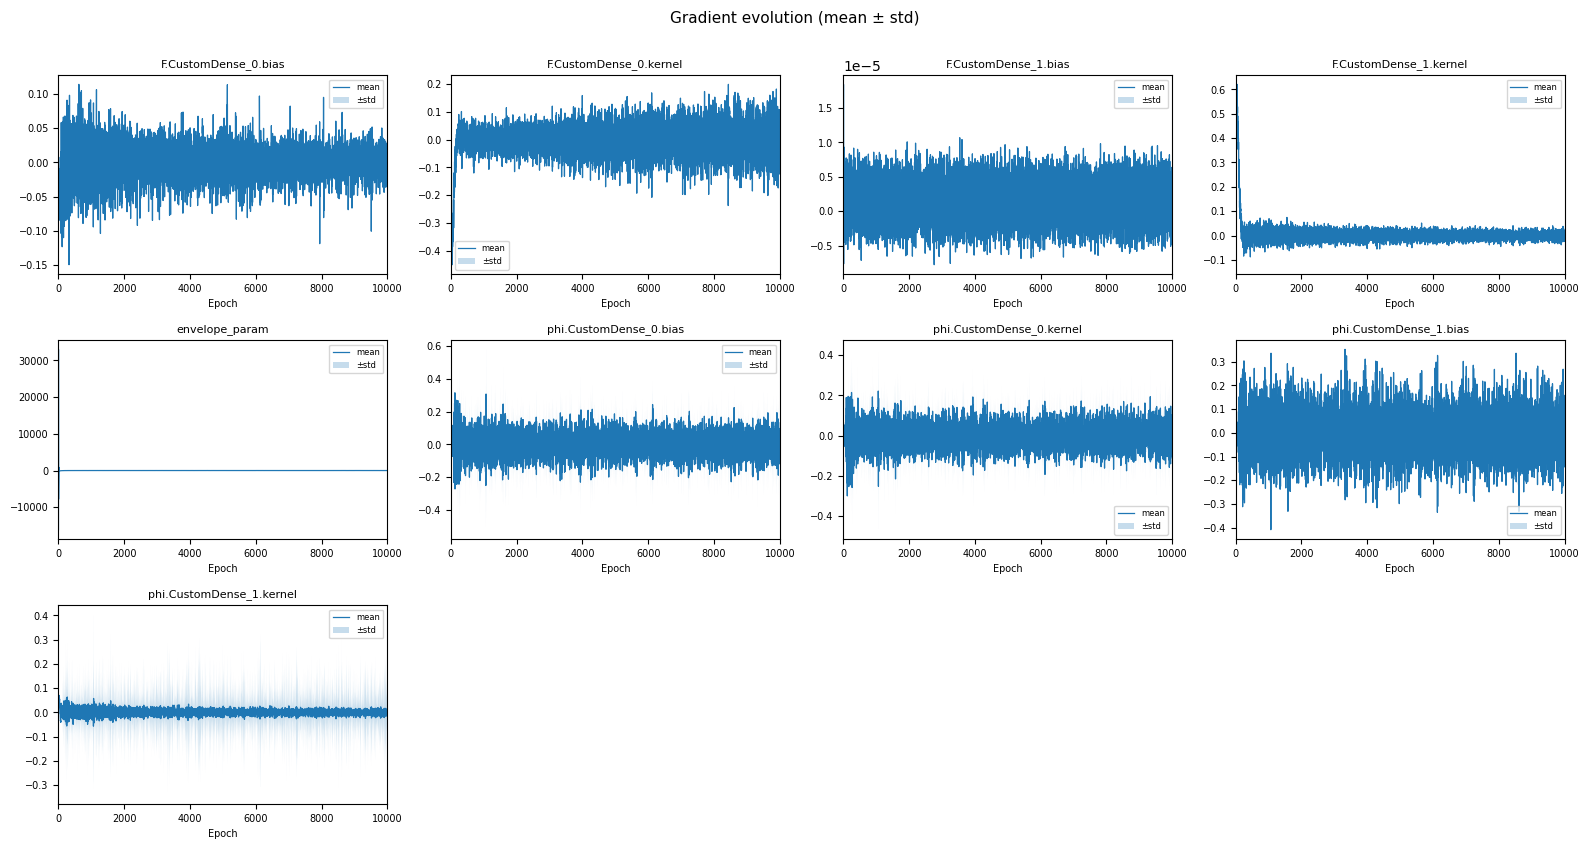

In [26]:
plot_dashboard(grad_stats, mode='mean_std', title='Gradient evolution (mean ± std)', xrange=XRANGE);

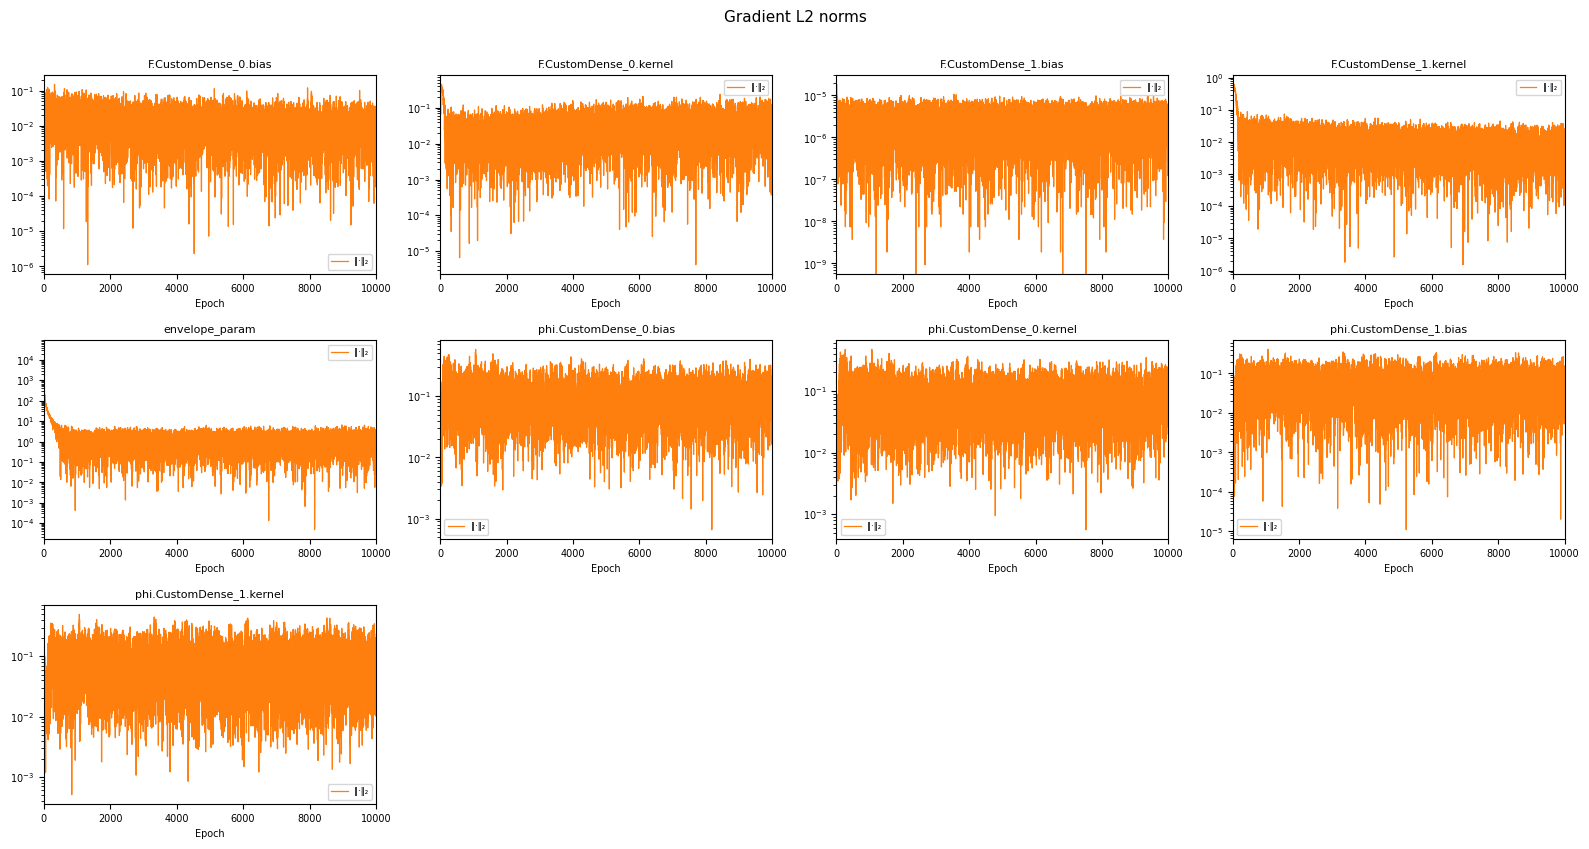

In [27]:
plot_dashboard(grad_stats, mode='norm', title='Gradient L2 norms', log_scale=True , xrange=XRANGE);

In [28]:
import csv

with open("lr-vs-not-working.csv", "r") as f:
    reader = csv.reader(f, delimiter=';')
    data = list(reader)
    
lrs = []
epoch = []
for row in data:
    if len(row) < 2:
        continue

    lr = row[0]
    ep = row[1]
    try:
        lr = float(lr)
        ep = int(ep)
    except ValueError:
        continue

    lrs.append(lr)
    epoch.append(ep)

print(lrs, epoch)

[0.025, 0.01, 0.005, 0.05] [1422, 3027, 7266, 873]


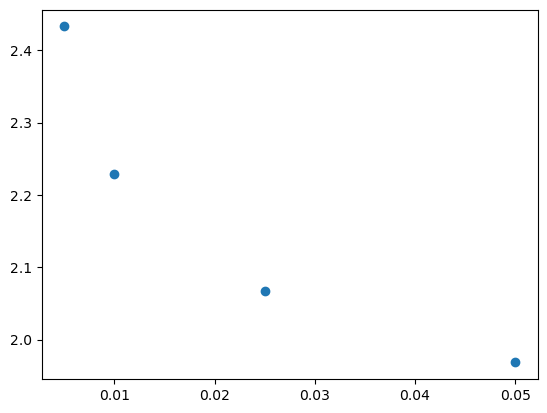

In [29]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(lrs, np.array(epoch)**(1/10), marker='o')